# Project

**Описание**
  
Интернет-магазин собирает историю покупателей, проводит рассылки предложений и
планирует будущие продажи. Для оптимизации процессов надо выделить пользователей,
которые готовы совершить покупку в ближайшее время.

**Цель**

Предсказать вероятность покупки в течение 90 дней

**Задачи**
 - Изучить данные
 - Разработать полезные признаки
 - Создать модель для классификации пользователей
 - Улучшить модель и максимизировать метрику roc_auc
 - Выполнить тестирование

In [89]:
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

# для преобразования списка_как_строка в список
import ast

Из apparel-purchases:
 - сформировать client_id

Из apparel-messages:
 - сформировать bulk_campaign_id

Узнать какие клиенты сдеалил покупки из bulk_campaign_id в 90 дней.

![](./scheme_01.png)

In [2]:
# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

## apparel-purchases

Данные о покупках клиентов по дням и по товарам. В каждой записи покупка определенного товара, его цена, количество штук.

В таблице есть списки идентификаторов, к каким категориям относится товар.

Часто это вложенные категории (например автотовары-аксессуары-освежители), но также может включать в начале списка маркер распродажи или маркер женщинам/мужчинам.

Нумерация категорий сквозная для всех уровней, то есть 44 на второй позиции списка или на третьей – это одна и та же категория. Иногда дерево категорий обновляется, поэтому могут меняться вложенности, например ['4', '28', '44', '1594'] или ['4', '44', '1594'].

Как обработать такие случаи – можете предлагать свои варианты решения.
 - `client_id` - идентификатор клиента
 - `quantity` - количество единиц товара
 - `price` - цена товара
 - `category_ids` - идентификаторы категорий
 - `date` - дата покупки
 - `message_id` - идентификатор сообщения из рассылки

In [3]:
!head -n 5 ./data/apparel-purchases.csv

client_id,quantity,price,category_ids,date,message_id
1515915625468169594,1,1999.0,"['4', '28', '57', '431']",2022-05-16,1515915625468169594-4301-627b661e9736d
1515915625468169594,1,2499.0,"['4', '28', '57', '431']",2022-05-16,1515915625468169594-4301-627b661e9736d
1515915625471138230,1,6499.0,"['4', '28', '57', '431']",2022-05-16,1515915625471138230-4437-6282242f27843
1515915625471138230,1,4999.0,"['4', '28', '244', '432']",2022-05-16,1515915625471138230-4437-6282242f27843


In [4]:
df_apparel_purchases = pd.read_csv('./data/apparel-purchases.csv')

In [5]:
df_apparel_purchases.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202208 entries, 0 to 202207
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   client_id     202208 non-null  int64  
 1   quantity      202208 non-null  int64  
 2   price         202208 non-null  float64
 3   category_ids  202208 non-null  object 
 4   date          202208 non-null  object 
 5   message_id    202208 non-null  object 
dtypes: float64(1), int64(2), object(3)
memory usage: 9.3+ MB


In [6]:
df_apparel_purchases.head(5)

,client_id,quantity,price,category_ids,date,message_id
0,1515915625468169594,1,1999.0,"['4', '28', '57', '431']",2022-05-16,1515915625468169594-4301-627b661e9736d
1,1515915625468169594,1,2499.0,"['4', '28', '57', '431']",2022-05-16,1515915625468169594-4301-627b661e9736d
2,1515915625471138230,1,6499.0,"['4', '28', '57', '431']",2022-05-16,1515915625471138230-4437-6282242f27843
3,1515915625471138230,1,4999.0,"['4', '28', '244', '432']",2022-05-16,1515915625471138230-4437-6282242f27843
4,1515915625471138230,1,4999.0,"['4', '28', '49', '413']",2022-05-16,1515915625471138230-4437-6282242f27843


## apparel-messages

Рассылки, которые были отправлены клиентам из таблицы покупок.
 - `bulk_campaign_id` - идентификатор рассылки
 - `client_id` - идентификатор клиента
 - `message_id` - идентификатор сообщения
 - `event` - действие с сообщением (отправлено, открыто, покупка...)
 - `channel` - канал рассылки
 - `date` - дата действия
 - `created_at` - дата-время полностью

In [7]:
!head -n 5 ./data/apparel-messages.csv

bulk_campaign_id,client_id,message_id,event,channel,date,created_at
4439,1515915625626736623,1515915625626736623-4439-6283415ac07ea,open,email,2022-05-19,2022-05-19 00:14:20
4439,1515915625490086521,1515915625490086521-4439-62834150016dd,open,email,2022-05-19,2022-05-19 00:39:34
4439,1515915625553578558,1515915625553578558-4439-6283415b36b4f,open,email,2022-05-19,2022-05-19 00:51:49
4439,1515915625553578558,1515915625553578558-4439-6283415b36b4f,click,email,2022-05-19,2022-05-19 00:52:20


In [8]:
df_apparel_messages = pd.read_csv('./data/apparel-messages.csv')

In [9]:
df_apparel_messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12739798 entries, 0 to 12739797
Data columns (total 7 columns):
 #   Column            Dtype 
---  ------            ----- 
 0   bulk_campaign_id  int64 
 1   client_id         int64 
 2   message_id        object
 3   event             object
 4   channel           object
 5   date              object
 6   created_at        object
dtypes: int64(2), object(5)
memory usage: 680.4+ MB


In [10]:
df_apparel_messages.head(5)

,bulk_campaign_id,client_id,message_id,event,channel,date,created_at
0,4439,1515915625626736623,1515915625626736623-4439-6283415ac07ea,open,email,2022-05-19,2022-05-19 00:14:20
1,4439,1515915625490086521,1515915625490086521-4439-62834150016dd,open,email,2022-05-19,2022-05-19 00:39:34
2,4439,1515915625553578558,1515915625553578558-4439-6283415b36b4f,open,email,2022-05-19,2022-05-19 00:51:49
3,4439,1515915625553578558,1515915625553578558-4439-6283415b36b4f,click,email,2022-05-19,2022-05-19 00:52:20
4,4439,1515915625471518311,1515915625471518311-4439-628341570c133,open,email,2022-05-19,2022-05-19 00:56:52


In [49]:
temp = df_apparel_messages.copy()

df_apparel_messages['date'] = pd.to_datetime(df_apparel_messages['date'], format="%Y-%m-%d")

In [50]:
df_apparel_messages['date'].min()

Timestamp('2022-05-19 00:00:00')

In [51]:
df_apparel_messages['date'].max()

Timestamp('2024-02-15 00:00:00')

## target
 - `client_id` - идентификатор клиента
 - `target` - клиент совершил покупку в целевом периоде

Общая база рассылок огромна, поэтому собрали для вас агрегированную по дням
статистику по рассылкам.

Если будете создавать на основе этой статистики дополнительные
признаки, обратите внимание, что нельзя суммировать по колонкам `nunique`, потому что это
уникальные клиенты в пределах дня, у вас нет данных, повторяются ли они в другие дни)

In [11]:
!head -n 5 ./data/apparel-target_binary.csv

client_id,target
1515915625468060902,0
1515915625468061003,1
1515915625468061099,0
1515915625468061100,0


In [12]:
df_apparel_target_binary = pd.read_csv('./data/apparel-target_binary.csv')

In [13]:
df_apparel_target_binary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49849 entries, 0 to 49848
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   client_id  49849 non-null  int64
 1   target     49849 non-null  int64
dtypes: int64(2)
memory usage: 779.0 KB


In [14]:
df_apparel_target_binary.head(5)

,client_id,target
0,1515915625468060902,0
1,1515915625468061003,1
2,1515915625468061099,0
3,1515915625468061100,0
4,1515915625468061170,0


In [15]:
df_apparel_target_binary.nunique()

client_id    49849
target           2
dtype: int64

## full_campaign_daily_event

Агрегация общей базы рассылок по дням и типам событий
 - `date` - дата
 - `bulk_campaign_id` - идентификатор рассылки
 - `count_event`* - общее количество каждого события event
 - `nunique_event`* - количество уникальных client_id в каждом событии

`*` в именах колонок найдете все типы событий event

In [16]:
!head -n 5 ./data/full_campaign_daily_event.csv

date,bulk_campaign_id,count_click,count_complain,count_hard_bounce,count_open,count_purchase,count_send,count_soft_bounce,count_subscribe,count_unsubscribe,nunique_click,nunique_complain,nunique_hard_bounce,nunique_open,nunique_purchase,nunique_send,nunique_soft_bounce,nunique_subscribe,nunique_unsubscribe,count_hbq_spam,nunique_hbq_spam,count_close,nunique_close
2022-05-19,563,0,0,0,4,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0
2022-05-19,577,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
2022-05-19,622,0,0,0,2,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0
2022-05-19,634,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0


In [17]:
df_full_campaign_daily_event = pd.read_csv('./data/full_campaign_daily_event.csv')

In [18]:
df_full_campaign_daily_event.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131072 entries, 0 to 131071
Data columns (total 24 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   date                 131072 non-null  object
 1   bulk_campaign_id     131072 non-null  int64 
 2   count_click          131072 non-null  int64 
 3   count_complain       131072 non-null  int64 
 4   count_hard_bounce    131072 non-null  int64 
 5   count_open           131072 non-null  int64 
 6   count_purchase       131072 non-null  int64 
 7   count_send           131072 non-null  int64 
 8   count_soft_bounce    131072 non-null  int64 
 9   count_subscribe      131072 non-null  int64 
 10  count_unsubscribe    131072 non-null  int64 
 11  nunique_click        131072 non-null  int64 
 12  nunique_complain     131072 non-null  int64 
 13  nunique_hard_bounce  131072 non-null  int64 
 14  nunique_open         131072 non-null  int64 
 15  nunique_purchase     131072 non-nu

In [19]:
df_full_campaign_daily_event.head(5)

,date,bulk_campaign_id,count_click,count_complain,count_hard_bounce,count_open,count_purchase,count_send,count_soft_bounce,count_subscribe,...,nunique_open,nunique_purchase,nunique_send,nunique_soft_bounce,nunique_subscribe,nunique_unsubscribe,count_hbq_spam,nunique_hbq_spam,count_close,nunique_close
0,2022-05-19,563,0,0,0,4,0,0,0,0,...,4,0,0,0,0,0,0,0,0,0
1,2022-05-19,577,0,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
2,2022-05-19,622,0,0,0,2,0,0,0,0,...,2,0,0,0,0,0,0,0,0,0
3,2022-05-19,634,0,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,2022-05-19,676,0,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0


## full_campaign_daily_event_channel

Агрегация по дням с учетом событий и каналов рассылки
 - `date` - дата
 - `bulk_campaign_id` - идентификатор рассылки
 - `count_event*_channel`* - общее количество каждого события по каналам
 - `nunique_event*_channel`* - количество уникальных client_id по событиям и каналам

`*` в именах колонок есть все типы событий event и каналов рассылки channel

In [20]:
!head -n 5 ./data/full_campaign_daily_event_channel.csv

date,bulk_campaign_id,count_click_email,count_click_mobile_push,count_open_email,count_open_mobile_push,count_purchase_email,count_purchase_mobile_push,count_soft_bounce_email,count_subscribe_email,count_unsubscribe_email,nunique_click_email,nunique_click_mobile_push,nunique_open_email,nunique_open_mobile_push,nunique_purchase_email,nunique_purchase_mobile_push,nunique_soft_bounce_email,nunique_subscribe_email,nunique_unsubscribe_email,count_hard_bounce_mobile_push,count_send_mobile_push,nunique_hard_bounce_mobile_push,nunique_send_mobile_push,count_hard_bounce_email,count_hbq_spam_email,count_send_email,nunique_hard_bounce_email,nunique_hbq_spam_email,nunique_send_email,count_soft_bounce_mobile_push,nunique_soft_bounce_mobile_push,count_complain_email,nunique_complain_email,count_close_mobile_push,nunique_close_mobile_push
2022-05-19,563,0,0,4,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2022-05-19,577,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,

In [21]:
df_full_campaign_daily_event_channel = pd.read_csv('./data/full_campaign_daily_event_channel.csv')

In [22]:
df_full_campaign_daily_event_channel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131072 entries, 0 to 131071
Data columns (total 36 columns):
 #   Column                           Non-Null Count   Dtype 
---  ------                           --------------   ----- 
 0   date                             131072 non-null  object
 1   bulk_campaign_id                 131072 non-null  int64 
 2   count_click_email                131072 non-null  int64 
 3   count_click_mobile_push          131072 non-null  int64 
 4   count_open_email                 131072 non-null  int64 
 5   count_open_mobile_push           131072 non-null  int64 
 6   count_purchase_email             131072 non-null  int64 
 7   count_purchase_mobile_push       131072 non-null  int64 
 8   count_soft_bounce_email          131072 non-null  int64 
 9   count_subscribe_email            131072 non-null  int64 
 10  count_unsubscribe_email          131072 non-null  int64 
 11  nunique_click_email              131072 non-null  int64 
 12  nunique_click_mo

In [23]:
df_full_campaign_daily_event_channel.head(5)

,date,bulk_campaign_id,count_click_email,count_click_mobile_push,count_open_email,count_open_mobile_push,count_purchase_email,count_purchase_mobile_push,count_soft_bounce_email,count_subscribe_email,...,count_send_email,nunique_hard_bounce_email,nunique_hbq_spam_email,nunique_send_email,count_soft_bounce_mobile_push,nunique_soft_bounce_mobile_push,count_complain_email,nunique_complain_email,count_close_mobile_push,nunique_close_mobile_push
0,2022-05-19,563,0,0,4,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2022-05-19,577,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2022-05-19,622,0,0,2,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2022-05-19,634,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2022-05-19,676,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Data Analysis

In [24]:
df_apparel_purchases.shape

(202208, 6)

In [25]:
df_apparel_purchases.head(5)

,client_id,quantity,price,category_ids,date,message_id
0,1515915625468169594,1,1999.0,"['4', '28', '57', '431']",2022-05-16,1515915625468169594-4301-627b661e9736d
1,1515915625468169594,1,2499.0,"['4', '28', '57', '431']",2022-05-16,1515915625468169594-4301-627b661e9736d
2,1515915625471138230,1,6499.0,"['4', '28', '57', '431']",2022-05-16,1515915625471138230-4437-6282242f27843
3,1515915625471138230,1,4999.0,"['4', '28', '244', '432']",2022-05-16,1515915625471138230-4437-6282242f27843
4,1515915625471138230,1,4999.0,"['4', '28', '49', '413']",2022-05-16,1515915625471138230-4437-6282242f27843


In [26]:
df_apparel_purchases.columns.tolist()

['client_id', 'quantity', 'price', 'category_ids', 'date', 'message_id']

In [27]:
# df_apparel_purchases['date'] = df_apparel_purchases['date']
temp = df_apparel_purchases.copy()

df_apparel_purchases['date'] = pd.to_datetime(df_apparel_purchases['date'], format="%Y-%m-%d")

In [28]:
df_apparel_purchases.head(5)

,client_id,quantity,price,category_ids,date,message_id
0,1515915625468169594,1,1999.0,"['4', '28', '57', '431']",2022-05-16,1515915625468169594-4301-627b661e9736d
1,1515915625468169594,1,2499.0,"['4', '28', '57', '431']",2022-05-16,1515915625468169594-4301-627b661e9736d
2,1515915625471138230,1,6499.0,"['4', '28', '57', '431']",2022-05-16,1515915625471138230-4437-6282242f27843
3,1515915625471138230,1,4999.0,"['4', '28', '244', '432']",2022-05-16,1515915625471138230-4437-6282242f27843
4,1515915625471138230,1,4999.0,"['4', '28', '49', '413']",2022-05-16,1515915625471138230-4437-6282242f27843


<Figure size 1200x600 with 0 Axes>

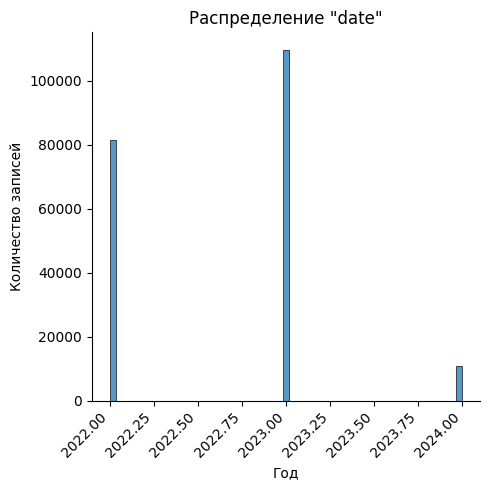

In [48]:
plt.figure(figsize=(12, 6))
sns.displot(df_apparel_purchases['date'].dt.year)
plt.title('Распределение "date"')
plt.xlabel('Год')
plt.ylabel('Количество записей')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [33]:
rows = df_apparel_purchases['client_id'] == 1515915625468169594

df_apparel_purchases[rows]

,client_id,quantity,price,category_ids,date,message_id
0,1515915625468169594,1,1999.0,"['4', '28', '57', '431']",2022-05-16,1515915625468169594-4301-627b661e9736d
1,1515915625468169594,1,2499.0,"['4', '28', '57', '431']",2022-05-16,1515915625468169594-4301-627b661e9736d
41172,1515915625468169594,1,742.0,"['2', '18', '258', '1569']",2022-10-19,1515915625468169594-7180-634d2f82d8799
149569,1515915625468169594,1,1050.0,"['4', '28', '124', '1602']",2023-06-30,1515915625468169594-13392-649554cd9b5ee
149570,1515915625468169594,1,864.0,"['4', '28', '124', '1602']",2023-06-30,1515915625468169594-13392-649554cd9b5ee
179933,1515915625468169594,1,4599.0,"['4', '28', '62', '657']",2023-11-22,1515915625468169594-14161-655db26e4d76f
179934,1515915625468169594,1,4599.0,"['4', '28', '62', '657']",2023-11-22,1515915625468169594-14161-655db26e4d76f
179935,1515915625468169594,1,3999.0,"['4', '28', '62', '657']",2023-11-22,1515915625468169594-14161-655db26e4d76f
179936,1515915625468169594,1,3261.0,"['4', '28', '62', '657']",2023-11-22,1515915625468169594-14161-655db26e4d76f


In [37]:
df_apparel_messages.head(5)

,bulk_campaign_id,client_id,message_id,event,channel,date,created_at
0,4439,1515915625626736623,1515915625626736623-4439-6283415ac07ea,open,email,2022-05-19,2022-05-19 00:14:20
1,4439,1515915625490086521,1515915625490086521-4439-62834150016dd,open,email,2022-05-19,2022-05-19 00:39:34
2,4439,1515915625553578558,1515915625553578558-4439-6283415b36b4f,open,email,2022-05-19,2022-05-19 00:51:49
3,4439,1515915625553578558,1515915625553578558-4439-6283415b36b4f,click,email,2022-05-19,2022-05-19 00:52:20
4,4439,1515915625471518311,1515915625471518311-4439-628341570c133,open,email,2022-05-19,2022-05-19 00:56:52


In [35]:
df_apparel_messages.columns.to_list()

['bulk_campaign_id',
 'client_id',
 'message_id',
 'event',
 'channel',
 'date',
 'created_at']

In [41]:
rows = df_apparel_messages['message_id'].isin([
    "1515915625468169594-4301-627b661e9736d",
    "1515915625468169594-7180-634d2f82d8799",
    "1515915625468169594-13392-649554cd9b5ee",
    "1515915625468169594-14161-655db26e4d76f"
])

df_apparel_messages[rows]

,bulk_campaign_id,client_id,message_id,event,channel,date,created_at
1981067,7180,1515915625468169594,1515915625468169594-7180-634d2f82d8799,send,email,2022-10-17,2022-10-17 12:06:46
2001255,7180,1515915625468169594,1515915625468169594-7180-634d2f82d8799,open,email,2022-10-17,2022-10-17 15:18:17
2038586,7180,1515915625468169594,1515915625468169594-7180-634d2f82d8799,click,email,2022-10-19,2022-10-19 13:02:41
2038588,7180,1515915625468169594,1515915625468169594-7180-634d2f82d8799,open,email,2022-10-19,2022-10-19 13:02:49
2047783,7180,1515915625468169594,1515915625468169594-7180-634d2f82d8799,purchase,email,2022-10-19,2022-10-19 16:57:08
5851006,13392,1515915625468169594,1515915625468169594-13392-649554cd9b5ee,send,email,2023-06-23,2023-06-23 08:17:34
5871646,13392,1515915625468169594,1515915625468169594-13392-649554cd9b5ee,open,email,2023-06-23,2023-06-23 10:41:24
6004827,13392,1515915625468169594,1515915625468169594-13392-649554cd9b5ee,open,email,2023-06-30,2023-06-30 16:58:41
6004829,13392,1515915625468169594,1515915625468169594-13392-649554cd9b5ee,click,email,2023-06-30,2023-06-30 16:59:01
6004877,13392,1515915625468169594,1515915625468169594-13392-649554cd9b5ee,purchase,email,2023-06-30,2023-06-30 17:10:25


In [38]:
rows = df_apparel_messages['client_id'] == 1515915625468169594

df_apparel_messages[rows]

,bulk_campaign_id,client_id,message_id,event,channel,date,created_at
1308,4463,1515915625468169594,1515915625468169594-4463-6285e40442c50,send,email,2022-05-19,2022-05-19 06:31:47
9157,4463,1515915625468169594,1515915625468169594-4463-6285e40442c50,open,email,2022-05-19,2022-05-19 08:02:13
101835,4568,1515915625468169594,1515915625468169594-4568-628ddb4b07e71,send,email,2022-05-25,2022-05-25 08:34:40
104015,4568,1515915625468169594,1515915625468169594-4568-628ddb4b07e71,open,email,2022-05-25,2022-05-25 08:41:54
119374,4591,1515915625468169594,1515915625468169594-4591-628f1e827259b,send,email,2022-05-26,2022-05-26 06:36:00
...,...,...,...,...,...,...,...
12541739,14625,1515915625468169594,1515915625468169594-14625-65c5ed58c2066,open,email,2024-02-09,2024-02-09 15:47:22
12626173,14641,1515915625468169594,1515915625468169594-14641-65cb249358ae1,send,email,2024-02-13,2024-02-13 09:31:17
12641233,14641,1515915625468169594,1515915625468169594-14641-65cb249358ae1,open,email,2024-02-13,2024-02-13 10:51:33
12643893,14624,1515915625468169594,1515915625468169594-14624-65c5e2327aa23,send,email,2024-02-13,2024-02-13 11:15:27


In [52]:
df_apparel_messages['date'].min(), df_apparel_purchases['date'].min()

(Timestamp('2022-05-19 00:00:00'), Timestamp('2022-05-16 00:00:00'))

In [53]:
df_apparel_messages['date'].max(), df_apparel_purchases['date'].max()

(Timestamp('2024-02-15 00:00:00'), Timestamp('2024-02-16 00:00:00'))

**Заметки**

Датафреймы `df_apparel_messages` и `df_apparel_purchases` отличаются по временным рамкам

In [54]:
df_apparel_target_binary.head(5)

,client_id,target
0,1515915625468060902,0
1,1515915625468061003,1
2,1515915625468061099,0
3,1515915625468061100,0
4,1515915625468061170,0


1515915625468060902 - предположим, что это клиент, который не делает покупки в течение 90 дней, рассмотрим подробнее

In [64]:
rows = (df_apparel_messages['client_id'] == 1515915625468060902) & (df_apparel_messages['event'] == "purchase")

df_apparel_messages[rows]

,bulk_campaign_id,client_id,message_id,event,channel,date,created_at
155216,4617,1515915625468060902,1515915625468060902-4617-6290657dac196,purchase,email,2022-05-27,2022-05-27 11:26:49
155237,4617,1515915625468060902,1515915625468060902-4617-6290657dac196,purchase,email,2022-05-27,2022-05-27 11:31:31
155312,4617,1515915625468060902,1515915625468060902-4617-6290657dac196,purchase,email,2022-05-27,2022-05-27 11:41:14
155528,4617,1515915625468060902,1515915625468060902-4617-6290657dac196,purchase,email,2022-05-27,2022-05-27 12:14:50
155602,4617,1515915625468060902,1515915625468060902-4617-6290657dac196,purchase,email,2022-05-27,2022-05-27 12:28:27


In [71]:
rows = (df_apparel_messages['client_id'] == 1515915625468060902)

df_apparel_messages[rows]

,bulk_campaign_id,client_id,message_id,event,channel,date,created_at
1644,4463,1515915625468060902,1515915625468060902-4463-6285e404c62b9,send,email,2022-05-19,2022-05-19 06:32:28
86730,4568,1515915625468060902,1515915625468060902-4568-628ddb1f311b5,send,email,2022-05-25,2022-05-25 07:43:38
115903,4591,1515915625468060902,1515915625468060902-4591-628f1e7ee9206,send,email,2022-05-26,2022-05-26 06:31:29
127441,4617,1515915625468060902,1515915625468060902-4617-6290657dac196,send,email,2022-05-27,2022-05-27 05:49:50
155015,4617,1515915625468060902,1515915625468060902-4617-6290657dac196,open,email,2022-05-27,2022-05-27 10:57:52
...,...,...,...,...,...,...,...
11506053,14468,1515915625468060902,1515915625468060902-14468-65a0ff51e2939,send,email,2024-01-12,2024-01-12 11:56:04
11601467,14477,1515915625468060902,1515915625468060902-14477-65a649033818e,send,email,2024-01-16,2024-01-16 09:23:07
11696316,14502,1515915625468060902,1515915625468060902-14502-65aa3659736fc,send,email,2024-01-19,2024-01-19 08:51:17
11750229,14502,1515915625468060902,1515915625468060902-14502-65aa3659736fc,open,email,2024-01-19,2024-01-19 19:28:46


In [73]:
rows = (df_apparel_messages['client_id'] == 1515915625468060902) \
    & (df_apparel_messages['message_id'] == "1515915625468060902-4463-6285e404c62b9")

df_apparel_messages[rows]

,bulk_campaign_id,client_id,message_id,event,channel,date,created_at
1644,4463,1515915625468060902,1515915625468060902-4463-6285e404c62b9,send,email,2022-05-19,2022-05-19 06:32:28


In [70]:
df_apparel_messages['event'].unique()

array(['open', 'click', 'purchase', 'send', 'unsubscribe', 'hbq_spam',
       'hard_bounce', 'subscribe', 'soft_bounce', 'complain', 'close'],
      dtype=object)

In [75]:
df_apparel_messages['channel'].unique()

array(['email', 'mobile_push'], dtype=object)

**Заметки**
 
 - В `df_apparel_messages` содержится история действий пользователя:
     - `open` - открыл письмо
     - `click` - перешел по ссылке
     - `purchase` - совершил оплату (покупка!)
     - `send` - письмо отправлено
     - `unsubscribe` - клиент отписался от рассылки
     - `hbq_spam` - клиент отметил как спам
     - `hard_bounce` - ошибки отправки (необратимая)
     - `subscribe` - клиент подписался на рассылку
     - `soft_bounce` - ошибка отправки (обратимая)
     - `complain` - жалобы на рассылку (спам)
     - `close` - клиент завершил подписку (?)

Можно рассматривать 

# Формулировка задачи

необходимо классифицировать клиентов на два типа:
 - Совершил покупку с момента рассылки менее чем за 90 дней
 - Не совершил покупку за 90 дней с момента рыссылки

Информация по рассылкам и датам содержится в `df_apparel_messages`:
 - Признак начала отсчета периода в 90 дней считаем дату отправки `df_apparel_messages.event == "send"`
 - Признак совершения покупки `df_apparel_messages.event == "purchase"`

Дополнительные категории из `df_apparel_purchases`:

 - `quantity`
 - `price`
 - `category_ids`


In [74]:
df_apparel_purchases.head(5)

,client_id,quantity,price,category_ids,date,message_id
0,1515915625468169594,1,1999.0,"['4', '28', '57', '431']",2022-05-16,1515915625468169594-4301-627b661e9736d
1,1515915625468169594,1,2499.0,"['4', '28', '57', '431']",2022-05-16,1515915625468169594-4301-627b661e9736d
2,1515915625471138230,1,6499.0,"['4', '28', '57', '431']",2022-05-16,1515915625471138230-4437-6282242f27843
3,1515915625471138230,1,4999.0,"['4', '28', '244', '432']",2022-05-16,1515915625471138230-4437-6282242f27843
4,1515915625471138230,1,4999.0,"['4', '28', '49', '413']",2022-05-16,1515915625471138230-4437-6282242f27843


## Рассмотрим категории

In [90]:
df_apparel_purchases['__category_ids_list'] = df_apparel_purchases['category_ids'].apply(lambda x: ast.literal_eval(x))

In [91]:
df_apparel_purchases['__cat_lenght'] = df_apparel_purchases['__category_ids_list'].apply(lambda x: len(x))

In [93]:
df_apparel_purchases['__cat_lenght'].head(5)

0    4
1    4
2    4
3    4
4    4
Name: __cat_lenght, dtype: int64

In [94]:
df_apparel_purchases['__cat_lenght'].describe()

count    202208.000000
mean          3.866741
std           0.699441
min           0.000000
25%           4.000000
50%           4.000000
75%           4.000000
max           5.000000
Name: __cat_lenght, dtype: float64

In [103]:
rows = df_apparel_purchases['__cat_lenght'] == 0

df_apparel_purchases[rows].head(5)

,client_id,quantity,price,category_ids,date,message_id,__cat_lenght,__category_ids_list
22153,1515915625558323436,1,1.0,[],2022-07-09,1515915625487742246-5335-62c7d2d1281c7,0,[]
22154,1515915625558323436,1,1.0,[],2022-07-09,1515915625487742246-5335-62c7d2d1281c7,0,[]
49215,1515915625474537721,1,7.0,[],2022-11-12,1515915625474537721-7803-636dfed5eb8b6,0,[]
53223,1515915625720375281,1,5.0,[],2022-11-13,1515915625720375281-7818-636f6ec29a382,0,[]
59056,1515915625867975448,1,7.0,[],2022-11-16,1515915625766044118-7879-63748749d81b5,0,[]


In [97]:
df_apparel_purchases[rows].shape

(5579, 8)

In [98]:
df_apparel_purchases.shape

(202208, 8)

In [99]:
df_apparel_purchases[rows]['price'].describe()

count     5579.000000
mean        46.114357
std        673.695729
min          1.000000
25%          5.000000
50%          7.000000
75%          7.000000
max      16999.000000
Name: price, dtype: float64

<Figure size 1200x600 with 0 Axes>

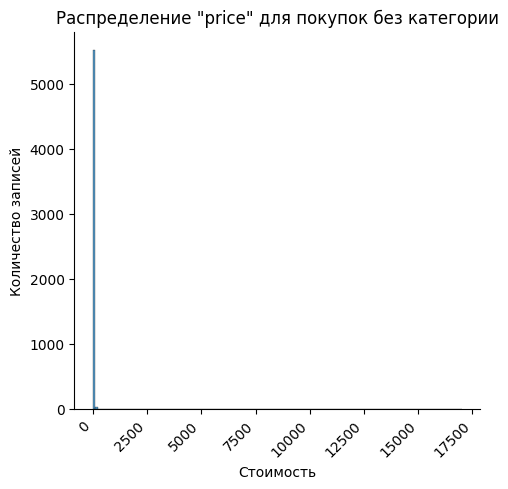

In [100]:
plt.figure(figsize=(12, 6))
sns.displot(df_apparel_purchases[rows]['price'])
plt.title('Распределение "price" для покупок без категории')
plt.xlabel('Стоимость')
plt.ylabel('Количество записей')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [113]:
rows = (df_apparel_purchases['__cat_lenght'] == 0) & (df_apparel_purchases['price'] > 10)

<Figure size 1200x600 with 0 Axes>

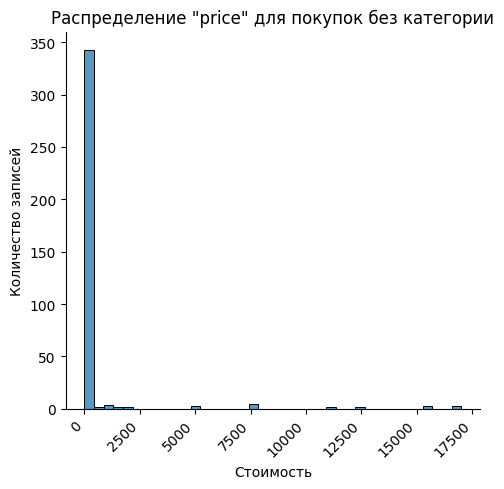

In [114]:
plt.figure(figsize=(12, 6))
sns.displot(df_apparel_purchases[rows]['price'])
plt.title('Распределение "price" для покупок без категории')
plt.xlabel('Стоимость')
plt.ylabel('Количество записей')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [108]:
df_apparel_purchases[rows]['price'].describe()

count     5576.000000
mean        36.993364
std        547.149041
min          1.000000
25%          5.000000
50%          7.000000
75%          7.000000
max      15499.000000
Name: price, dtype: float64

In [115]:
df_apparel_purchases['price'].describe()

count    202208.000000
mean       1193.301516
std        1342.252664
min           1.000000
25%         352.000000
50%         987.000000
75%        1699.000000
max       85499.000000
Name: price, dtype: float64

<Figure size 1200x600 with 0 Axes>

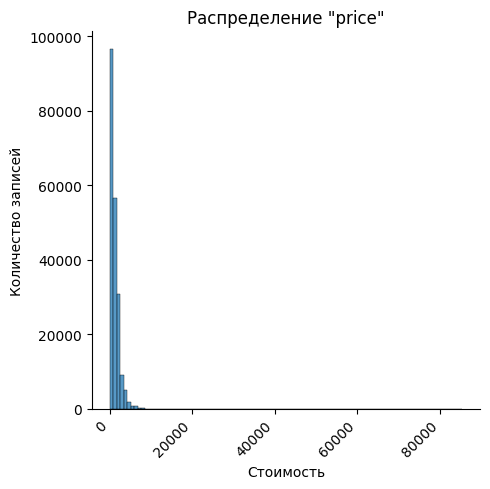

In [117]:
plt.figure(figsize=(12, 6))
sns.displot(df_apparel_purchases['price'], bins=100)
plt.title('Распределение "price"')
plt.xlabel('Стоимость')
plt.ylabel('Количество записей')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Вероятность будет зависеть от статуса рассылки

```
df_apparel_messages.event = ['send', 'open'] -> 50%
df_apparel_messages.event = ['send', 'open', 'click', 'open', 'click'] -> 75%
df_apparel_messages.event = ['send', 'open', 'unsubscribe'] -> 0%
и т.д.
```

То есть можно ввести признаки соответствующие статусу